In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
RAW_PATH = "../data/raw/mhs_raw.csv"  # change if your raw file has a different name
PROCESSED_PATH = "../data/processed/mhs_main_experiment_annotations_with_split.csv"
SOFT_PATH = "../data/processed/mhs_comment_soft_labels.csv"

In [3]:
ann = pd.read_csv(PROCESSED_PATH)

print("Processed annotation-level shape:", ann.shape)
print("Unique comments:", ann["comment_id"].nunique())
print("Unique annotators:", ann["annotator_id"].nunique())
print("\nSplits:")
print(ann["split"].value_counts())

Processed annotation-level shape: (49433, 53)
Unique comments: 19761
Unique annotators: 7851

Splits:
split
train         34413
test           7713
validation     7307
Name: count, dtype: int64


In [4]:
required_cols = [
    "comment_id",
    "annotator_id",
    "text_clean",
    "split",
    "target_type",
    "is_women_targeted",
    "is_immigrant_targeted",
    "annotator_gender_group",
    "annotator_ideology_group",
    "hatespeech",
    "insult",
    "dehumanize",
    "violence",
    "genocide"
]

missing_cols = [col for col in required_cols if col not in ann.columns]

print("Missing required columns:", missing_cols)

if len(missing_cols) == 0:
    print("All required columns are present.")

Missing required columns: []
All required columns are present.


In [5]:
missing_summary = (
    ann[required_cols]
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["column", "missing_count"]
missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(ann) * 100
).round(2)

missing_summary

,column,missing_count,missing_percent
0,comment_id,0,0.0
1,annotator_id,0,0.0
2,text_clean,0,0.0
3,split,0,0.0
4,target_type,0,0.0
5,is_women_targeted,0,0.0
6,is_immigrant_targeted,0,0.0
7,annotator_gender_group,0,0.0
8,annotator_ideology_group,0,0.0
9,hatespeech,0,0.0


In [6]:
comment_split_counts = (
    ann.groupby("comment_id")["split"]
    .nunique()
    .reset_index(name="num_splits")
)

leaked_comments = comment_split_counts[comment_split_counts["num_splits"] > 1]

print("Comments appearing in more than one split:", len(leaked_comments))

if len(leaked_comments) == 0:
    print("No comment-level leakage detected.")
else:
    leaked_comments.head()

Comments appearing in more than one split: 0
No comment-level leakage detected.


In [7]:
split_summary = (
    ann.groupby("split")
    .agg(
        annotation_rows=("comment_id", "count"),
        unique_comments=("comment_id", "nunique"),
        unique_annotators=("annotator_id", "nunique")
    )
    .reset_index()
)

split_summary

,split,annotation_rows,unique_comments,unique_annotators
0,test,7713,2965,4871
1,train,34413,13832,7697
2,validation,7307,2964,4608


In [8]:
target_summary = (
    ann.groupby("target_type")
    .agg(
        annotation_rows=("comment_id", "count"),
        unique_comments=("comment_id", "nunique"),
        unique_annotators=("annotator_id", "nunique")
    )
    .sort_values("unique_comments", ascending=False)
)

target_summary

,annotation_rows,unique_comments,unique_annotators
target_type,,,
women_only,26905,11596,7377
immigrant_only,21544,8222,7134
women_and_immigrant,984,609,842


In [23]:
target_by_split = (
    ann.groupby(["split", "target_type"])
    .agg(
        annotation_rows=("comment_id", "count"),
        unique_comments=("comment_id", "nunique")
    )
    .reset_index()
    .sort_values(["target_type", "split"])
)

target_by_split

,split,target_type,annotation_rows,unique_comments
0,test,immigrant_only,2942,1234
3,train,immigrant_only,15289,5747
6,validation,immigrant_only,3313,1241
1,test,women_and_immigrant,123,96
4,train,women_and_immigrant,622,421
7,validation,women_and_immigrant,239,92
2,test,women_only,4648,1742
5,train,women_only,18502,8117
8,validation,women_only,3755,1737


In [9]:
task_specs = {
    "hatespeech": [0, 1, 2],
    "sentiment": [0, 1, 2, 3, 4],
    "respect": [0, 1, 2, 3, 4],
    "insult": [0, 1, 2, 3, 4],
    "humiliate": [0, 1, 2, 3, 4],
    "status": [0, 1, 2, 3, 4],
    "dehumanize": [0, 1, 2, 3, 4],
    "violence": [0, 1, 2, 3, 4],
    "genocide": [0, 1, 2, 3, 4],
    "attack_defend": [0, 1, 2, 3, 4],
}

range_rows = []

for task, expected_values in task_specs.items():
    if task in ann.columns:
        observed_values = sorted(ann[task].dropna().unique().tolist())
        unexpected_values = [v for v in observed_values if v not in expected_values]

        range_rows.append({
            "task": task,
            "expected_values": expected_values,
            "observed_values": observed_values,
            "unexpected_values": unexpected_values,
            "valid": len(unexpected_values) == 0
        })

label_range_audit = pd.DataFrame(range_rows)
label_range_audit

,task,expected_values,observed_values,unexpected_values,valid
0,hatespeech,"[0, 1, 2]","[0.0, 1.0, 2.0]",[],True
1,sentiment,"[0, 1, 2, 3, 4]","[0.0, 1.0, 2.0, 3.0, 4.0]",[],True
2,respect,"[0, 1, 2, 3, 4]","[0.0, 1.0, 2.0, 3.0, 4.0]",[],True
3,insult,"[0, 1, 2, 3, 4]","[0.0, 1.0, 2.0, 3.0, 4.0]",[],True
4,humiliate,"[0, 1, 2, 3, 4]","[0.0, 1.0, 2.0, 3.0, 4.0]",[],True
5,status,"[0, 1, 2, 3, 4]","[0.0, 1.0, 2.0, 3.0, 4.0]",[],True
6,dehumanize,"[0, 1, 2, 3, 4]","[0.0, 1.0, 2.0, 3.0, 4.0]",[],True
7,violence,"[0, 1, 2, 3, 4]","[0.0, 1.0, 2.0, 3.0, 4.0]",[],True
8,genocide,"[0, 1, 2, 3, 4]","[0.0, 1.0, 2.0, 3.0, 4.0]",[],True
9,attack_defend,"[0, 1, 2, 3, 4]","[0.0, 1.0, 2.0, 3.0, 4.0]",[],True


In [10]:
raw_label_rows = []

for task, labels in task_specs.items():
    if task not in ann.columns:
        continue

    counts = ann[task].value_counts().sort_index()
    percents = ann[task].value_counts(normalize=True).sort_index() * 100

    for label in labels:
        raw_label_rows.append({
            "task": task,
            "label": label,
            "annotation_count": counts.get(label, 0),
            "annotation_percent": round(percents.get(label, 0), 2)
        })

raw_label_distribution = pd.DataFrame(raw_label_rows)
raw_label_distribution

,task,label,annotation_count,annotation_percent
0,hatespeech,0,29951,60.59
1,hatespeech,1,3582,7.25
2,hatespeech,2,15900,32.16
3,sentiment,0,2732,5.53
4,sentiment,1,2844,5.75
5,sentiment,2,6361,12.87
6,sentiment,3,13517,27.34
7,sentiment,4,23979,48.51
8,respect,0,3661,7.41
9,respect,1,3075,6.22


In [11]:
annotation_count_summary = (
    ann.groupby("comment_id")
    .agg(
        annotation_count=("annotator_id", "count"),
        unique_annotators=("annotator_id", "nunique"),
        split=("split", "first"),
        target_type=("target_type", "first")
    )
    .reset_index()
)

annotation_count_summary[["annotation_count", "unique_annotators"]].describe()

,annotation_count,unique_annotators
count,19761.000000,19761.000000
mean,2.501543,2.501543
std,17.017415,17.017415
min,1.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,2.000000
75%,2.000000,2.000000
max,737.000000,737.000000


In [12]:
def make_distribution(group, label_col, label_values):
    counts = group[label_col].value_counts(normalize=True)
    return np.array([counts.get(label, 0.0) for label in label_values])

def entropy(probs):
    probs = probs[probs > 0]
    if len(probs) == 0:
        return 0.0
    return -np.sum(probs * np.log2(probs))

entropy_rows = []

for task, labels in task_specs.items():
    if task not in ann.columns:
        continue

    task_entropies = []

    for _, group in ann.groupby("comment_id"):
        dist = make_distribution(group, task, labels)
        task_entropies.append(entropy(dist))

    task_entropies = np.array(task_entropies)

    entropy_rows.append({
        "task": task,
        "mean_entropy": task_entropies.mean(),
        "median_entropy": np.median(task_entropies),
        "zero_entropy_percent": round((task_entropies == 0).mean() * 100, 2),
        "max_entropy": task_entropies.max(),
        "num_comments": len(task_entropies)
    })

entropy_summary = pd.DataFrame(entropy_rows)
entropy_summary

,task,mean_entropy,median_entropy,zero_entropy_percent,max_entropy,num_comments
0,hatespeech,0.225016,0.0,77.46,1.584963,19761
1,sentiment,0.311847,0.0,69.10,2.279532,19761
2,respect,0.321791,0.0,68.46,2.136204,19761
3,insult,0.380469,0.0,63.17,2.074032,19761
4,humiliate,0.423250,0.0,60.33,2.194461,19761
5,status,0.348724,0.0,66.26,2.321928,19761
6,dehumanize,0.468168,0.0,57.76,2.238942,19761
7,violence,0.353410,0.0,66.10,2.269211,19761
8,genocide,0.244015,0.0,75.62,2.248174,19761
9,attack_defend,0.346131,0.0,66.02,2.183310,19761


In [13]:
women_ann = ann[ann["is_women_targeted"] == 1].copy()

gender_counts = (
    women_ann.groupby("comment_id")
    .agg(
        split=("split", "first"),
        text_clean=("text_clean", "first"),
        total_annotations=("annotator_id", "count"),
        women_annotations=("annotator_gender_group", lambda x: (x == "women").sum()),
        men_annotations=("annotator_gender_group", lambda x: (x == "men").sum()),
        non_binary_annotations=("annotator_gender_group", lambda x: (x == "non_binary").sum()),
        prefer_not_to_say_annotations=("annotator_gender_group", lambda x: (x == "prefer_not_to_say").sum()),
        self_describe_annotations=("annotator_gender_group", lambda x: (x == "self_describe").sum())
    )
    .reset_index()
)

gender_count_summary = gender_counts[
    [
        "total_annotations",
        "women_annotations",
        "men_annotations",
        "non_binary_annotations",
        "prefer_not_to_say_annotations",
        "self_describe_annotations"
    ]
].describe()

gender_count_summary

,total_annotations,women_annotations,men_annotations,non_binary_annotations,prefer_not_to_say_annotations,self_describe_annotations
count,11983.000000,11983.000000,11983.000000,11983.000000,11983.000000,11983.000000
mean,2.327380,1.310440,0.989235,0.017441,0.007678,0.002587
std,15.052045,8.755565,6.191982,0.180264,0.092848,0.050799
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,737.000000,422.000000,315.000000,9.000000,3.000000,1.000000


In [14]:
gender_threshold_rows = []

for threshold in [1, 2, 3, 4, 5]:
    gender_threshold_rows.append({
        "threshold": threshold,
        "total_comments": len(gender_counts),
        "women_at_least_threshold": (gender_counts["women_annotations"] >= threshold).sum(),
        "men_at_least_threshold": (gender_counts["men_annotations"] >= threshold).sum(),
        "both_women_and_men_at_least_threshold": (
            (gender_counts["women_annotations"] >= threshold) &
            (gender_counts["men_annotations"] >= threshold)
        ).sum(),
        "either_women_or_men_at_least_threshold": (
            (gender_counts["women_annotations"] >= threshold) |
            (gender_counts["men_annotations"] >= threshold)
        ).sum()
    })

gender_threshold_audit = pd.DataFrame(gender_threshold_rows)
gender_threshold_audit

,threshold,total_comments,women_at_least_threshold,men_at_least_threshold,both_women_and_men_at_least_threshold,either_women_or_men_at_least_threshold
0,1,11983,8630,7168,3869,11929
1,2,11983,2935,1900,271,4564
2,3,11983,641,343,24,960
3,4,11983,97,51,24,124
4,5,11983,27,22,21,28


In [15]:
gender_problem_examples = gender_counts[
    (gender_counts["women_annotations"] <= 1) &
    (gender_counts["men_annotations"] <= 1)
].head(10)

gender_problem_examples[
    [
        "comment_id",
        "split",
        "total_annotations",
        "women_annotations",
        "men_annotations",
        "text_clean"
    ]
]

,comment_id,split,total_annotations,women_annotations,men_annotations,text_clean
0,6,train,2,1,1,First off you look cool as fuck! Anyway if we ...
1,11,validation,2,1,1,"eat my fuck, bitch"
6,29,train,1,1,0,I'm absolutely for equal rights for all people...
7,31,train,1,0,1,"OKAY, I'LL LEAVE YOU FUCK YOURSELF LIKE A FUCK..."
8,35,train,1,1,0,"Joe Rogan...listen, dawg. That one time I had ..."
9,37,train,1,1,0,She got pregnant 4 times with two different gu...
10,44,train,2,1,1,"I mean, by this logic they want to ban sex, ri..."
11,55,train,1,1,0,Aww that's too bad for you. I'll start with yo...
16,78,train,1,1,0,Typical stupid bimbo who has it all decides to...
19,97,train,2,1,1,Not tall**er** or strong**er** specifically bu...


In [16]:
immigrant_ann = ann[ann["is_immigrant_targeted"] == 1].copy()

ideology_groups = [
    "extremely_conservative",
    "conservative",
    "slightly_conservative",
    "neutral",
    "slightly_liberal",
    "liberal",
    "extremely_liberal",
    "no_opinion",
    "unknown"
]

ideology_count_dict = {}

for group in ideology_groups:
    ideology_count_dict[f"{group}_annotations"] = (
        "annotator_ideology_group",
        lambda x, group=group: (x == group).sum()
    )

ideology_counts = (
    immigrant_ann.groupby("comment_id")
    .agg(
        split=("split", "first"),
        text_clean=("text_clean", "first"),
        total_annotations=("annotator_id", "count"),
        **ideology_count_dict
    )
    .reset_index()
)

ideology_annotation_cols = [
    f"{group}_annotations"
    for group in ideology_groups
    if f"{group}_annotations" in ideology_counts.columns
]

ideology_count_summary = ideology_counts[
    ["total_annotations"] + ideology_annotation_cols
].describe()

ideology_count_summary

,total_annotations,extremely_conservative_annotations,conservative_annotations,slightly_conservative_annotations,neutral_annotations,slightly_liberal_annotations,liberal_annotations,extremely_liberal_annotations,no_opinion_annotations,unknown_annotations
count,8621.000000,8621.000000,8621.000000,8621.000000,8621.000000,8621.000000,8621.000000,8621.000000,8621.000000,8621.000000
mean,2.613154,0.088389,0.290222,0.289758,0.439624,0.417817,0.656420,0.357035,0.072961,0.000928
std,18.498833,0.697913,2.003531,2.095133,3.147124,2.995957,4.746379,2.715792,0.590441,0.030450
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,702.000000,27.000000,85.000000,85.000000,119.000000,118.000000,180.000000,114.000000,25.000000,1.000000


In [17]:
ideology_threshold_rows = []

for threshold in [1, 2, 3, 4, 5]:
    row = {
        "threshold": threshold,
        "total_comments": len(ideology_counts),
        "comments_with_total_at_least_threshold": (
            ideology_counts["total_annotations"] >= threshold
        ).sum()
    }

    for group in ideology_groups:
        col = f"{group}_annotations"
        if col in ideology_counts.columns:
            row[f"{group}_at_least_threshold"] = (
                ideology_counts[col] >= threshold
            ).sum()

    ideology_threshold_rows.append(row)

ideology_threshold_audit = pd.DataFrame(ideology_threshold_rows)
ideology_threshold_audit

,threshold,total_comments,comments_with_total_at_least_threshold,extremely_conservative_at_least_threshold,conservative_at_least_threshold,slightly_conservative_at_least_threshold,neutral_at_least_threshold,slightly_liberal_at_least_threshold,liberal_at_least_threshold,extremely_liberal_at_least_threshold,no_opinion_at_least_threshold,unknown_at_least_threshold
0,1,8621,8621,518,1608,1598,2325,2220,3297,1909,435,8
1,2,8621,4257,43,132,113,286,275,493,208,35,0
2,3,8621,1787,25,36,37,44,45,77,41,22,0
3,4,8621,469,22,32,34,33,31,39,31,17,0
4,5,8621,49,20,31,32,32,31,36,27,16,0


In [18]:
ideology_cols_for_examples = [
    "comment_id",
    "split",
    "total_annotations",
    "liberal_annotations",
    "neutral_annotations",
    "conservative_annotations",
    "slightly_liberal_annotations",
    "slightly_conservative_annotations",
    "text_clean"
]

available_example_cols = [
    col for col in ideology_cols_for_examples
    if col in ideology_counts.columns
]

ideology_problem_examples = ideology_counts[
    ideology_counts[ideology_annotation_cols].max(axis=1) <= 1
].head(10)

ideology_problem_examples[available_example_cols]

,comment_id,split,total_annotations,liberal_annotations,neutral_annotations,conservative_annotations,slightly_liberal_annotations,slightly_conservative_annotations,text_clean
0,7,test,2,1,0,0,0,0,\*points to posters asking for palestinian rig...
1,10,train,3,1,1,0,0,1,"They'll come back in your plan, also. Plus we ..."
2,13,train,2,1,0,0,0,0,Do they realize that a random Japanese person ...
3,23,validation,1,0,0,0,0,1,"Build the wall, and put these spics in prison ..."
4,24,train,1,0,0,1,0,0,Love from an Indian from USA.
5,29,train,2,1,0,0,0,1,I'm absolutely for equal rights for all people...
6,32,train,1,0,0,0,0,1,The native european hunter-gatherer culture go...
7,35,train,1,0,0,0,1,0,"Joe Rogan...listen, dawg. That one time I had ..."
9,41,train,2,1,0,1,0,0,"Give me your tired, your poor, your religious ..."
10,48,train,1,1,0,0,0,0,"Give me your tired, your poor, your religious ..."


In [19]:
soft = pd.read_csv(SOFT_PATH)

print("Soft-label comment-level shape:", soft.shape)
print("Unique comments:", soft["comment_id"].nunique())

soft_required_cols = [
    "comment_id",
    "text_clean",
    "split",
    "hatespeech_0_prob",
    "hatespeech_1_prob",
    "hatespeech_2_prob",
    "hatespeech_entropy"
]

missing_soft_cols = [
    col for col in soft_required_cols
    if col not in soft.columns
]

print("Missing soft-label columns:", missing_soft_cols)

Soft-label comment-level shape: (19761, 23)
Unique comments: 19761
Missing soft-label columns: []


In [20]:
soft["hatespeech_prob_sum"] = soft[
    ["hatespeech_0_prob", "hatespeech_1_prob", "hatespeech_2_prob"]
].sum(axis=1)

soft_prob_sum_summary = soft["hatespeech_prob_sum"].describe()
soft_prob_sum_summary

count    1.976100e+04
mean     1.000000e+00
std      5.057183e-18
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: hatespeech_prob_sum, dtype: float64

In [21]:
processing_findings = [
    {
        "finding": "Comment-level split leakage",
        "status": "PASS" if len(leaked_comments) == 0 else "FAIL",
        "evidence": f"{len(leaked_comments)} comments appear in multiple splits."
    },
    {
        "finding": "Required columns present",
        "status": "PASS" if len(missing_cols) == 0 else "CHECK",
        "evidence": f"Missing columns: {missing_cols}"
    },
    {
        "finding": "Soft-label probability sums",
        "status": "PASS" if np.allclose(soft['hatespeech_prob_sum'], 1.0) else "CHECK",
        "evidence": f"Min={soft['hatespeech_prob_sum'].min()}, Max={soft['hatespeech_prob_sum'].max()}"
    },
    {
        "finding": "Gender subgroup density",
        "status": "LIMITATION",
        "evidence": "Most women/men subgroup distributions are based on only one subgroup annotator per comment."
    },
    {
        "finding": "Ideology subgroup density",
        "status": "LIMITATION",
        "evidence": "Most ideology subgroup distributions are too sparse for direct ideology-perspective prediction."
    },
    {
        "finding": "Global disagreement modelling",
        "status": "SUPPORTED",
        "evidence": "Global soft-label distributions can be formed using all annotators per comment."
    }
]

processing_findings_df = pd.DataFrame(processing_findings)
processing_findings_df

,finding,status,evidence
0,Comment-level split leakage,PASS,0 comments appear in multiple splits.
1,Required columns present,PASS,Missing columns: []
2,Soft-label probability sums,PASS,"Min=0.9999999999999998, Max=1.0"
3,Gender subgroup density,LIMITATION,Most women/men subgroup distributions are base...
4,Ideology subgroup density,LIMITATION,Most ideology subgroup distributions are too s...
5,Global disagreement modelling,SUPPORTED,Global soft-label distributions can be formed ...


In [27]:
os.makedirs("../results/tables", exist_ok=True)

report_path = "../results/tables/data_processing_and_feasibility_audit.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("DATA PROCESSING AND FEASIBILITY AUDIT\n")
    f.write("=" * 90 + "\n\n")

    
    f.write("2. PROCESSED DATASET SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(f"Annotation rows: {len(ann)}\n")
    f.write(f"Unique comments: {ann['comment_id'].nunique()}\n")
    f.write(f"Unique annotators: {ann['annotator_id'].nunique()}\n\n")
    f.write("Split summary:\n")
    f.write(split_summary.to_string(index=False))
    f.write("\n\n")

    f.write("3. PROCESSING VALIDATION CHECKS\n")
    f.write("-" * 90 + "\n")
    f.write(processing_findings_df.to_string(index=False))
    f.write("\n\n")

    f.write("4. MISSING VALUE SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(missing_summary.to_string(index=False))
    f.write("\n\n")

    f.write("5. TARGET TYPE SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(target_summary.to_string())
    f.write("\n\n")

    f.write("6. TARGET TYPE BY SPLIT\n")
    f.write("-" * 90 + "\n")
    f.write(target_by_split.to_string(index=False))
    f.write("\n\n")

    f.write("7. LABEL RANGE AUDIT\n")
    f.write("-" * 90 + "\n")
    f.write(label_range_audit.to_string(index=False))
    f.write("\n\n")

    f.write("8. RAW LABEL DISTRIBUTIONS\n")
    f.write("-" * 90 + "\n")
    f.write(raw_label_distribution.to_string(index=False))
    f.write("\n\n")

    f.write("9. ANNOTATION COUNT PER COMMENT SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(annotation_count_summary[["annotation_count", "unique_annotators"]].describe().to_string())
    f.write("\n\n")

    f.write("10. GLOBAL ENTROPY SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(entropy_summary.to_string(index=False))
    f.write("\n\n")

    f.write("11. GENDER SUBGROUP DENSITY SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(f"Women-targeted annotation rows: {len(women_ann)}\n")
    f.write(f"Women-targeted unique comments: {women_ann['comment_id'].nunique()}\n\n")
    f.write(gender_count_summary.to_string())
    f.write("\n\n")

    f.write("12. GENDER THRESHOLD AUDIT\n")
    f.write("-" * 90 + "\n")
    f.write(gender_threshold_audit.to_string(index=False))
    f.write("\n\n")

    f.write("13. GENDER PROBLEM EXAMPLES\n")
    f.write("-" * 90 + "\n")
    f.write(gender_problem_examples[
        [
            "comment_id",
            "split",
            "total_annotations",
            "women_annotations",
            "men_annotations",
            "text_clean"
        ]
    ].to_string(index=False))
    f.write("\n\n")

    f.write("14. IDEOLOGY SUBGROUP DENSITY SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(f"Immigrant-targeted annotation rows: {len(immigrant_ann)}\n")
    f.write(f"Immigrant-targeted unique comments: {immigrant_ann['comment_id'].nunique()}\n\n")
    f.write(ideology_count_summary.to_string())
    f.write("\n\n")

    f.write("15. IDEOLOGY THRESHOLD AUDIT\n")
    f.write("-" * 90 + "\n")
    f.write(ideology_threshold_audit.to_string(index=False))
    f.write("\n\n")

    f.write("16. IDEOLOGY PROBLEM EXAMPLES\n")
    f.write("-" * 90 + "\n")
    f.write(ideology_problem_examples[available_example_cols].to_string(index=False))
    f.write("\n\n")

    f.write("17. SOFT-LABEL FILE VALIDATION\n")
    f.write("-" * 90 + "\n")
    f.write(f"Soft-label rows: {len(soft)}\n")
    f.write(f"Unique comments: {soft['comment_id'].nunique()}\n")
    f.write(f"Missing soft-label columns: {missing_soft_cols}\n\n")
    f.write("Hatespeech probability sum summary:\n")
    f.write(soft_prob_sum_summary.to_string())
    f.write("\n\n")

    f
print(open(report_path, encoding="utf-8").read())

DATA PROCESSING AND FEASIBILITY AUDIT

2. PROCESSED DATASET SUMMARY
------------------------------------------------------------------------------------------
Annotation rows: 49433
Unique comments: 19761
Unique annotators: 7851

Split summary:
     split  annotation_rows  unique_comments  unique_annotators
      test             7713             2965               4871
     train            34413            13832               7697
validation             7307             2964               4608

3. PROCESSING VALIDATION CHECKS
------------------------------------------------------------------------------------------
                      finding     status                                                                                        evidence
  Comment-level split leakage       PASS                                                           0 comments appear in multiple splits.
     Required columns present       PASS                                                             

In [28]:
entropy_by_comment = []

for task, labels in task_specs.items():
    for comment_id, group in ann.groupby("comment_id"):
        dist = make_distribution(group, task, labels)
        entropy_value = entropy(dist)

        entropy_by_comment.append({
            "comment_id": comment_id,
            "task": task,
            "entropy": entropy_value,
            "annotation_count": len(group),
            "split": group["split"].iloc[0],
            "target_type": group["target_type"].iloc[0]
        })

entropy_by_comment = pd.DataFrame(entropy_by_comment)

entropy_by_comment.groupby("task")[["annotation_count", "entropy"]].describe()

annotation_count                                           \
                         count      mean        std  min  25%  50%  75%   
task                                                                      
attack_defend          19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   
dehumanize             19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   
genocide               19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   
hatespeech             19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   
humiliate              19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   
insult                 19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   
respect                19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   
sentiment              19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   
status                 19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   
violence               19761.0  2.501543  17.017415  1.0  1.0  2.0  2.0   

                      entropy                                               \
                 max    count      mean       std  min  25%  50%       75%   
task                                                                         
attack_defend  737.0  19761.0  0.346131  0.495383 -0.0  0.0  0.0  0.918296   
dehumanize     737.0  19761.0  0.468168  0.575103 -0.0  0.0  0.0  1.000000   
genocide       737.0  19761.0  0.244015  0.439457 -0.0  0.0  0.0  0.000000   
hatespeech     737.0  19761.0  0.225016  0.425825 -0.0  0.0  0.0  0.000000   
humiliate      737.0  19761.0  0.423250  0.543375 -0.0  0.0  0.0  1.000000   
insult         737.0  19761.0  0.380469  0.514693 -0.0  0.0  0.0  0.918296   
respect        737.0  19761.0  0.321791  0.487672 -0.0  0.0  0.0  0.918296   
sentiment      737.0  19761.0  0.311847  0.478404 -0.0  0.0  0.0  0.918296   
status         737.0  19761.0  0.348724  0.503432 -0.0  0.0  0.0  0.918296   
violence       737.0  19761.0  0.353410  0.510745 -0.0  0.0  0.0  0.918296   

                         
                    max  
task                     
attack_defend  2.183310  
dehumanize     2.238942  
genocide       2.248174  
hatespeech     1.584963  
humiliate      2.194461  
insult         2.074032  
respect        2.136204  
sentiment      2.279532  
status         2.321928  
violence       2.269211

In [29]:
low_annotation_entropy = (
    entropy_by_comment
    .groupby(["task", "annotation_count"])
    .agg(
        comments=("comment_id", "count"),
        mean_entropy=("entropy", "mean"),
        zero_entropy_percent=("entropy", lambda x: round((x == 0).mean() * 100, 2))
    )
    .reset_index()
)

low_annotation_entropy[low_annotation_entropy["annotation_count"] <= 5]

,task,annotation_count,comments,mean_entropy,zero_entropy_percent
0,attack_defend,1,9122,0.000000,100.00
1,attack_defend,2,5995,0.530776,46.92
2,attack_defend,3,3409,0.749021,26.55
3,attack_defend,4,1148,0.879660,17.51
4,attack_defend,5,30,0.899451,16.67
58,dehumanize,1,9122,0.000000,100.00
59,dehumanize,2,5995,0.697415,30.26
60,dehumanize,3,3409,1.039673,11.53
61,dehumanize,4,1148,1.210890,7.23
62,dehumanize,5,30,1.377603,3.33


In [30]:
pattern_rows = []

for task, labels in task_specs.items():
    dist_records = []

    for comment_id, group in ann.groupby("comment_id"):
        dist = make_distribution(group, task, labels)
        rounded = tuple(np.round(dist, 3))

        dist_records.append({
            "comment_id": comment_id,
            "task": task,
            "distribution_pattern": rounded
        })

    temp = pd.DataFrame(dist_records)

    pattern_counts = (
        temp["distribution_pattern"]
        .value_counts()
        .reset_index()
    )

    pattern_counts.columns = ["distribution_pattern", "count"]
    pattern_counts["task"] = task
    pattern_counts["percent"] = round(pattern_counts["count"] / len(temp) * 100, 2)

    pattern_rows.append(pattern_counts.head(10))

distribution_patterns = pd.concat(pattern_rows, ignore_index=True)

distribution_patterns[["task", "distribution_pattern", "count", "percent"]]

,task,distribution_pattern,count,percent
0,hatespeech,"(1.0, 0.0, 0.0)",11082,56.08
1,hatespeech,"(0.0, 0.0, 1.0)",3366,17.03
2,hatespeech,"(0.5, 0.0, 0.5)",1325,6.71
3,hatespeech,"(0.0, 1.0, 0.0)",858,4.34
4,hatespeech,"(0.5, 0.5, 0.0)",598,3.03
...,...,...,...,...
95,attack_defend,"(0.0, 1.0, 0.0, 0.0, 0.0)",864,4.37
96,attack_defend,"(1.0, 0.0, 0.0, 0.0, 0.0)",585,2.96
97,attack_defend,"(0.0, 0.0, 0.0, 0.667, 0.333)",487,2.46
98,attack_defend,"(0.0, 0.0, 0.333, 0.667, 0.0)",437,2.21


In [31]:
split_entropy_summary = (
    entropy_by_comment
    .groupby(["task", "split"])
    .agg(
        mean_entropy=("entropy", "mean"),
        median_entropy=("entropy", "median"),
        zero_entropy_percent=("entropy", lambda x: round((x == 0).mean() * 100, 2)),
        comments=("comment_id", "count")
    )
    .reset_index()
)

split_entropy_summary

,task,split,mean_entropy,median_entropy,zero_entropy_percent,comments
0,attack_defend,test,0.352028,-0.0,65.70,2965
1,attack_defend,train,0.347841,-0.0,65.79,13832
2,attack_defend,validation,0.332252,-0.0,67.41,2964
3,dehumanize,test,0.463173,-0.0,57.88,2965
4,dehumanize,train,0.468794,-0.0,57.76,13832
5,dehumanize,validation,0.470245,-0.0,57.59,2964
6,genocide,test,0.240419,-0.0,75.99,2965
7,genocide,train,0.245446,-0.0,75.51,13832
8,genocide,validation,0.240933,-0.0,75.81,2964
9,hatespeech,test,0.228469,-0.0,77.30,2965


In [32]:
def entropy_group(x):
    if x == 0:
        return "zero_entropy"
    elif x < 0.5:
        return "low_disagreement"
    elif x < 1.0:
        return "medium_disagreement"
    else:
        return "high_disagreement"

entropy_by_comment["entropy_group"] = entropy_by_comment["entropy"].apply(entropy_group)

entropy_group_summary = (
    entropy_by_comment
    .groupby(["task", "entropy_group"])
    .size()
    .reset_index(name="comments")
)

entropy_group_summary["percent"] = (
    entropy_group_summary
    .groupby("task")["comments"]
    .transform(lambda x: round(x / x.sum() * 100, 2))
)

entropy_group_summary

,task,entropy_group,comments,percent
0,attack_defend,high_disagreement,4130,20.90
1,attack_defend,low_disagreement,5,0.03
2,attack_defend,medium_disagreement,2580,13.06
3,attack_defend,zero_entropy,13046,66.02
4,dehumanize,high_disagreement,6208,31.42
5,dehumanize,medium_disagreement,2140,10.83
6,dehumanize,zero_entropy,11413,57.76
7,genocide,high_disagreement,2774,14.04
8,genocide,low_disagreement,6,0.03
9,genocide,medium_disagreement,2037,10.31


In [33]:
comment_annotation_counts = (
    ann.groupby("comment_id")
    .size()
    .reset_index(name="annotation_count")
)

for threshold in [1, 2, 3, 5]:
    kept = comment_annotation_counts[
        comment_annotation_counts["annotation_count"] >= threshold
    ]

    print(f"Annotation threshold >= {threshold}")
    print("Comments kept:", len(kept))
    print("Percent kept:", round(len(kept) / ann["comment_id"].nunique() * 100, 2))
    print()

Annotation threshold >= 1
Comments kept: 19761
Percent kept: 100.0

Annotation threshold >= 2
Comments kept: 10639
Percent kept: 53.84

Annotation threshold >= 3
Comments kept: 4644
Percent kept: 23.5

Annotation threshold >= 5
Comments kept: 87
Percent kept: 0.44



In [34]:
os.makedirs("../results/tables", exist_ok=True)

diagnostic_report_path = "../results/tables/global_distribution_overfitting_diagnostic_summary.txt"

with open(diagnostic_report_path, "w", encoding="utf-8") as f:
    f.write("GLOBAL DISTRIBUTION MODELLING DIAGNOSTIC SUMMARY\n")
    f.write("=" * 90 + "\n\n")

    f.write("1. DATASET SIZE\n")
    f.write("-" * 90 + "\n")
    f.write(f"Annotation rows: {len(ann)}\n")
    f.write(f"Unique comments: {ann['comment_id'].nunique()}\n")
    f.write(f"Unique annotators: {ann['annotator_id'].nunique()}\n\n")

    f.write("2. ANNOTATION COUNT PER COMMENT\n")
    f.write("-" * 90 + "\n")
    f.write(annotation_count_summary[["annotation_count", "unique_annotators"]].describe().to_string())
    f.write("\n\n")

    f.write("3. GLOBAL ENTROPY SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(entropy_summary.to_string(index=False))
    f.write("\n\n")

    f.write("4. ENTROPY BY SPLIT\n")
    f.write("-" * 90 + "\n")
    f.write(split_entropy_summary.to_string(index=False))
    f.write("\n\n")

    f.write("5. ENTROPY GROUP SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(entropy_group_summary.to_string(index=False))
    f.write("\n\n")

    f.write("6. LOW ANNOTATION ENTROPY SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write(
        low_annotation_entropy[
            low_annotation_entropy["annotation_count"] <= 5
        ].to_string(index=False)
    )
    f.write("\n\n")

    f.write("7. MOST COMMON DISTRIBUTION PATTERNS\n")
    f.write("-" * 90 + "\n")
    f.write(distribution_patterns[["task", "distribution_pattern", "count", "percent"]].to_string(index=False))
    f.write("\n\n")

    f.write("8. SUBGROUP FEASIBILITY SUMMARY\n")
    f.write("-" * 90 + "\n")
    f.write("Gender subgroup threshold audit:\n")
    f.write(gender_threshold_audit.to_string(index=False))
    f.write("\n\n")

    f.write("Ideology subgroup threshold audit:\n")
    f.write(ideology_threshold_audit.to_string(index=False))
    f.write("\n\n")

    f.write("9. DATASET VARIANT RECOMMENDATIONS\n")
    f.write("-" * 90 + "\n")

    comment_annotation_counts = (
        ann.groupby("comment_id")
        .size()
        .reset_index(name="annotation_count")
    )

    for threshold in [1, 2, 3, 5]:
        kept = comment_annotation_counts[
            comment_annotation_counts["annotation_count"] >= threshold
        ]

        f.write(f"Annotation threshold >= {threshold}\n")
        f.write(f"- Comments kept: {len(kept)}\n")
        f.write(f"- Percent kept: {round(len(kept) / ann['comment_id'].nunique() * 100, 2)}%\n\n")



print("Saved diagnostic summary:", diagnostic_report_path)
print(open(diagnostic_report_path, encoding="utf-8").read())

Saved diagnostic summary: ../results/tables/global_distribution_overfitting_diagnostic_summary.txt
GLOBAL DISTRIBUTION MODELLING DIAGNOSTIC SUMMARY

1. DATASET SIZE
------------------------------------------------------------------------------------------
Annotation rows: 49433
Unique comments: 19761
Unique annotators: 7851

2. ANNOTATION COUNT PER COMMENT
------------------------------------------------------------------------------------------
       annotation_count  unique_annotators
count      19761.000000       19761.000000
mean           2.501543           2.501543
std           17.017415          17.017415
min            1.000000           1.000000
25%            1.000000           1.000000
50%            2.000000           2.000000
75%            2.000000           2.000000
max          737.000000         737.000000

3. GLOBAL ENTROPY SUMMARY
------------------------------------------------------------------------------------------
         task  mean_entropy  median_entropy  

In [35]:
# ============================================================
# RANK MHS DIMENSIONS BY VARIATION / DISAGREEMENT RICHNESS
# ============================================================

variation_rows = []

for task, labels in task_specs.items():
    if task not in ann.columns:
        continue

    # Raw annotation distribution
    raw_counts = ann[task].value_counts(normalize=True).reindex(labels, fill_value=0)

    # Class balance entropy: higher = labels are more evenly spread overall
    raw_probs = raw_counts.values
    raw_entropy = entropy(raw_probs)
    max_raw_entropy = np.log2(len(labels))
    normalized_raw_entropy = raw_entropy / max_raw_entropy if max_raw_entropy > 0 else 0

    # Comment-level entropy
    comment_entropies = []

    for _, group in ann.groupby("comment_id"):
        dist = make_distribution(group, task, labels)
        comment_entropies.append(entropy(dist))

    comment_entropies = np.array(comment_entropies)

    # Majority label concentration
    majority_labels = (
        ann.groupby("comment_id")[task]
        .agg(lambda x: x.value_counts().idxmax())
    )

    majority_distribution = majority_labels.value_counts(normalize=True)
    majority_top_class_percent = majority_distribution.max() * 100

    # Most common soft distribution pattern concentration
    patterns = []

    for _, group in ann.groupby("comment_id"):
        dist = make_distribution(group, task, labels)
        patterns.append(tuple(np.round(dist, 3)))

    pattern_counts = pd.Series(patterns).value_counts(normalize=True)
    top_pattern_percent = pattern_counts.iloc[0] * 100

    variation_rows.append({
        "task": task,
        "num_classes": len(labels),
        "raw_class_entropy": raw_entropy,
        "normalized_raw_class_entropy": normalized_raw_entropy,
        "mean_comment_entropy": comment_entropies.mean(),
        "median_comment_entropy": np.median(comment_entropies),
        "zero_entropy_percent": (comment_entropies == 0).mean() * 100,
        "nonzero_entropy_percent": (comment_entropies > 0).mean() * 100,
        "high_entropy_percent": (comment_entropies >= 1.0).mean() * 100,
        "majority_top_class_percent": majority_top_class_percent,
        "top_distribution_pattern_percent": top_pattern_percent,
    })

variation_ranking = pd.DataFrame(variation_rows)

# Higher variation score = more useful/rich for disagreement modelling
variation_ranking["variation_score"] = (
    variation_ranking["normalized_raw_class_entropy"]
    + variation_ranking["mean_comment_entropy"]
    + (variation_ranking["nonzero_entropy_percent"] / 100)
    + (variation_ranking["high_entropy_percent"] / 100)
    - (variation_ranking["top_distribution_pattern_percent"] / 100)
)

variation_ranking = variation_ranking.sort_values(
    "variation_score",
    ascending=False
).reset_index(drop=True)

variation_ranking

,task,num_classes,raw_class_entropy,normalized_raw_class_entropy,mean_comment_entropy,median_comment_entropy,zero_entropy_percent,nonzero_entropy_percent,high_entropy_percent,majority_top_class_percent,top_distribution_pattern_percent,variation_score
0,dehumanize,5,2.310006,0.994866,0.468168,0.0,57.755174,42.244826,31.415414,24.593897,14.002328,2.059613
1,humiliate,5,2.229068,0.960007,0.423250,0.0,60.330955,39.669045,27.275948,33.262487,20.039472,1.852312
2,insult,5,2.111463,0.909358,0.380469,0.0,63.174941,36.825059,23.662770,35.559941,22.407773,1.670627
3,attack_defend,5,2.040969,0.878997,0.346131,0.0,66.018926,33.981074,20.899752,39.380598,25.904559,1.514891
4,violence,5,1.966829,0.847067,0.353410,0.0,66.099894,33.900106,22.043419,52.563129,38.444411,1.375468
5,respect,5,1.949221,0.839484,0.321791,0.0,68.463134,31.536866,19.715601,40.959466,30.362836,1.370171
6,status,5,1.769505,0.762084,0.348724,0.0,66.261829,33.738171,21.451344,46.991549,34.714842,1.315555
7,sentiment,5,1.866336,0.803787,0.311847,0.0,69.095694,30.904306,18.678205,42.047467,31.582410,1.295635
8,hatespeech,3,1.238726,0.781549,0.225016,0.0,77.455594,22.544406,13.126866,67.466221,56.080158,0.802477
9,genocide,5,1.444444,0.622088,0.244015,0.0,75.623703,24.376297,14.037751,73.953747,59.961540,0.650628


In [36]:
variation_ranking_path = "../results/tables/mhs_dimension_variation_ranking.csv"
variation_ranking.to_csv(variation_ranking_path, index=False)

print("Saved:", variation_ranking_path)
display(variation_ranking)

Saved: ../results/tables/mhs_dimension_variation_ranking.csv


,task,num_classes,raw_class_entropy,normalized_raw_class_entropy,mean_comment_entropy,median_comment_entropy,zero_entropy_percent,nonzero_entropy_percent,high_entropy_percent,majority_top_class_percent,top_distribution_pattern_percent,variation_score
0,dehumanize,5,2.310006,0.994866,0.468168,0.0,57.755174,42.244826,31.415414,24.593897,14.002328,2.059613
1,humiliate,5,2.229068,0.960007,0.423250,0.0,60.330955,39.669045,27.275948,33.262487,20.039472,1.852312
2,insult,5,2.111463,0.909358,0.380469,0.0,63.174941,36.825059,23.662770,35.559941,22.407773,1.670627
3,attack_defend,5,2.040969,0.878997,0.346131,0.0,66.018926,33.981074,20.899752,39.380598,25.904559,1.514891
4,violence,5,1.966829,0.847067,0.353410,0.0,66.099894,33.900106,22.043419,52.563129,38.444411,1.375468
5,respect,5,1.949221,0.839484,0.321791,0.0,68.463134,31.536866,19.715601,40.959466,30.362836,1.370171
6,status,5,1.769505,0.762084,0.348724,0.0,66.261829,33.738171,21.451344,46.991549,34.714842,1.315555
7,sentiment,5,1.866336,0.803787,0.311847,0.0,69.095694,30.904306,18.678205,42.047467,31.582410,1.295635
8,hatespeech,3,1.238726,0.781549,0.225016,0.0,77.455594,22.544406,13.126866,67.466221,56.080158,0.802477
9,genocide,5,1.444444,0.622088,0.244015,0.0,75.623703,24.376297,14.037751,73.953747,59.961540,0.650628


In [37]:
# ============================================================
# ANNOTATOR WORKLOAD AUDIT
# ============================================================

annotator_activity = (
    ann.groupby("annotator_id")
    .agg(
        comments_annotated=("comment_id", "nunique"),
        total_annotation_rows=("comment_id", "count")
    )
    .reset_index()
)

annotator_summary = (
    annotator_activity[
        ["comments_annotated", "total_annotation_rows"]
    ]
    .describe()
)

annotator_summary

,comments_annotated,total_annotation_rows
count,7851.000000,7851.000000
mean,6.296395,6.296395
std,3.016627,3.016627
min,1.000000,1.000000
25%,4.000000,4.000000
50%,6.000000,6.000000
75%,8.000000,8.000000
max,22.000000,22.000000


In [39]:
print("Total annotators:", ann["annotator_id"].nunique())

print("\nAnnotators with only 1 annotation:")
print((annotator_activity["comments_annotated"] == 1).sum())

print("\nAnnotators with >=10 annotations:")
print((annotator_activity["comments_annotated"] >= 10).sum())

print("\nAnnotators with >=20 annotations:")
print((annotator_activity["comments_annotated"] >= 20).sum())

print("\nAnnotators with >=30 annotations:")
print((annotator_activity["comments_annotated"] >= 30).sum())

Total annotators: 7851

Annotators with only 1 annotation:
265

Annotators with >=10 annotations:
1159

Annotators with >=20 annotations:
2

Annotators with >=30 annotations:
0


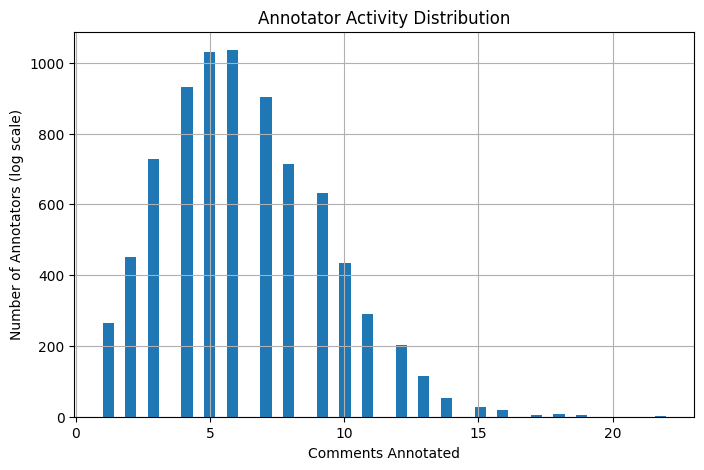

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    annotator_activity["comments_annotated"],
    bins=50,
    
)

plt.xlabel("Comments Annotated")
plt.ylabel("Number of Annotators (log scale)")
plt.title("Annotator Activity Distribution")

plt.grid(True)

plt.show()